# VisionInput Latency Analysis



In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

DEADLINE_MS = 33.33  # 30fps frame budget
NFR_TARGET = 33.0    # NFR target for median

PROJECT_ROOT = Path.cwd()
candidate_paths = [
    PROJECT_ROOT / 'merged_logs.xlsx',
    PROJECT_ROOT / 'logs' / 'merged_logs.xlsx'
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find merged_logs.xlsx in project root or logs/.')

df = pd.read_excel(data_path)

required_cols = ['latency_ms', 'camera_label']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df = df.copy()
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce')
df = df.dropna(subset=['latency_ms'])
df['camera_label'] = df['camera_label'].fillna('Unknown').astype(str).str.strip()
df.loc[df['camera_label'].eq(''), 'camera_label'] = 'Unknown'
df['source_type'] = np.where(df['camera_label'].str.contains('Camo', case=False, na=False), 'Camo', 'Native')

for stage_col in ['loop_ms', 'capture_ms', 'mediapipe_ms', 'output_ms']:
    if stage_col in df.columns:
        df[stage_col] = pd.to_numeric(df[stage_col], errors='coerce')

print(f'Loaded {len(df):,} latency rows from: {data_path}')
display(df.head())

Loaded 4,717 latency rows from: c:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\merged_logs.xlsx


,timestamp,camera_label,camera_resolution,mode,duration_s,frames,fps,capture_ms_per_frame,preprocess_ms_per_frame,mediapipe_ms_per_frame,...,mediapipe_ms,output_ms,loop_ms,read_failed_count,visualise_mode,websocket_enabled,requested_resolution,requested_fps,negotiated_fps,source_type
11,21:22:17,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
12,21:22:17,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
13,21:22:17,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
14,21:22:17,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
15,21:22:17,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native


In [5]:
lat = df['latency_ms']
n_trials = int(lat.count())
compliance_mask = lat <= DEADLINE_MS
outlier_mask = lat > 100

table_4_1 = pd.DataFrame({
    'metric': [
        'n_trials', 'min_ms', 'max_ms', 'mean_ms', 'median_ms', 'std_ms',
        'p90_ms', 'p95_ms', 'p99_ms', 'compliance_rate_pct', 'outlier_count_gt_100ms', 'nfr_verdict'
    ],
    'value': [
        n_trials,
        lat.min(),
        lat.max(),
        lat.mean(),
        lat.median(),
        lat.std(ddof=1),
        lat.quantile(0.90),
        lat.quantile(0.95),
        lat.quantile(0.99),
        compliance_mask.mean() * 100,
        int(outlier_mask.sum()),
        'PASS' if lat.median() <= NFR_TARGET else 'FAIL'
    ]
})

table_4_1_styled = table_4_1.style.format({
    'value': lambda x: f'{x:.2f}' if isinstance(x, (float, np.floating)) else f'{x}'
}).set_caption('Table 4.1 - Overall Latency Statistics')
display(table_4_1_styled)

per_camera = (
    df.groupby('camera_label', dropna=False)['latency_ms']
      .agg(n='count', median='median', mean='mean', std='std', max='max')
      .reset_index()
)
comp_per_camera = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS)
      .groupby('camera_label', dropna=False)['is_compliant']
      .mean()
      .mul(100)
      .reset_index(name='compliance_pct')
)
table_4_2 = per_camera.merge(comp_per_camera, on='camera_label', how='left')
table_4_2 = table_4_2[['camera_label', 'n', 'median', 'mean', 'std', 'compliance_pct', 'max']]

table_4_2_styled = table_4_2.style.format({
    'n': '{:,.0f}',
    'median': '{:.2f}',
    'mean': '{:.2f}',
    'std': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'max': '{:.2f}'
}).set_caption('Table 4.2 - Per-Camera Latency Breakdown')
display(table_4_2_styled)

table_4_3 = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS, is_outlier=df['latency_ms'] > 100)
      .groupby('source_type', dropna=False)
      .agg(
          n=('latency_ms', 'count'),
          median_ms=('latency_ms', 'median'),
          mean_ms=('latency_ms', 'mean'),
          std_ms=('latency_ms', 'std'),
          compliance_pct=('is_compliant', lambda s: s.mean() * 100),
          outliers_gt_100ms=('is_outlier', 'sum')
      )
      .reset_index()
)

table_4_3_styled = table_4_3.style.format({
    'n': '{:,.0f}',
    'median_ms': '{:.2f}',
    'mean_ms': '{:.2f}',
    'std_ms': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'outliers_gt_100ms': '{:,.0f}'
}).set_caption('Table 4.3 - Camo vs Native Comparison')
display(table_4_3_styled)

stats_cache = {
    'median': float(lat.median()),
    'p50': float(lat.quantile(0.50)),
    'p90': float(lat.quantile(0.90)),
    'p95': float(lat.quantile(0.95)),
    'p99': float(lat.quantile(0.99)),
    'verdict': 'PASS' if float(lat.median()) <= NFR_TARGET else 'FAIL'
}

,metric,value
0,n_trials,4717
1,min_ms,0.04
2,max_ms,386.89
3,mean_ms,33.87
4,median_ms,30.44
5,std_ms,15.31
6,p90_ms,46.66
7,p95_ms,47.75
8,p99_ms,108.46
9,compliance_rate_pct,74.05


,camera_label,n,median,mean,std,compliance_pct,max
0,Creative VF0700 Live,200,23.66,23.83,0.81,100.00,28.00
1,Creative VF0700 Live! Cam Chat HD,"1,200",31.05,40.51,21.75,62.67,179.69
2,Creative VF0700 Live! Cam Chat HD via Camo Studio,200,26.49,27.03,2.02,100.00,33.06
3,Insta360 3 GO 3s via Camo Studio,200,25.32,25.67,1.59,100.00,31.16
4,Insta360 Go 3S,"2,617",30.83,34.64,10.92,70.35,386.89
5,Samsunbg Note 20 ultra Wide 12MP via Camo Studio,200,25.45,25.80,1.49,100.00,29.77
6,Unknown,100,0.11,0.10,0.04,100.00,0.23


,source_type,n,median_ms,mean_ms,std_ms,compliance_pct,outliers_gt_100ms
0,Camo,600,25.66,26.17,1.82,100.00,0
1,Native,"4,117",30.74,34.99,16.07,70.27,53


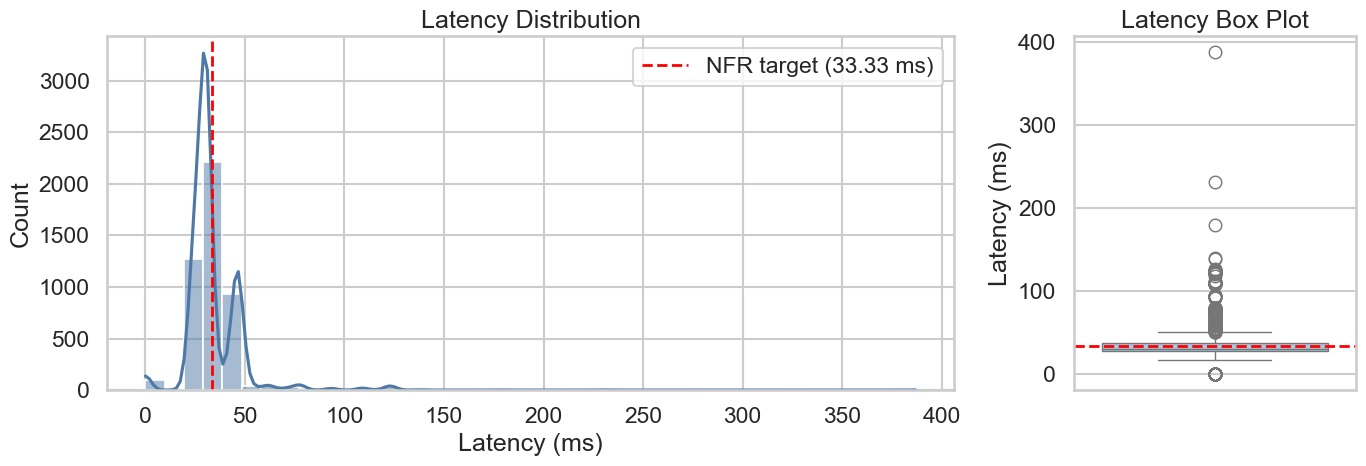

c:\temp\ipykernel_46408\1382390142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, palette=palette_map)


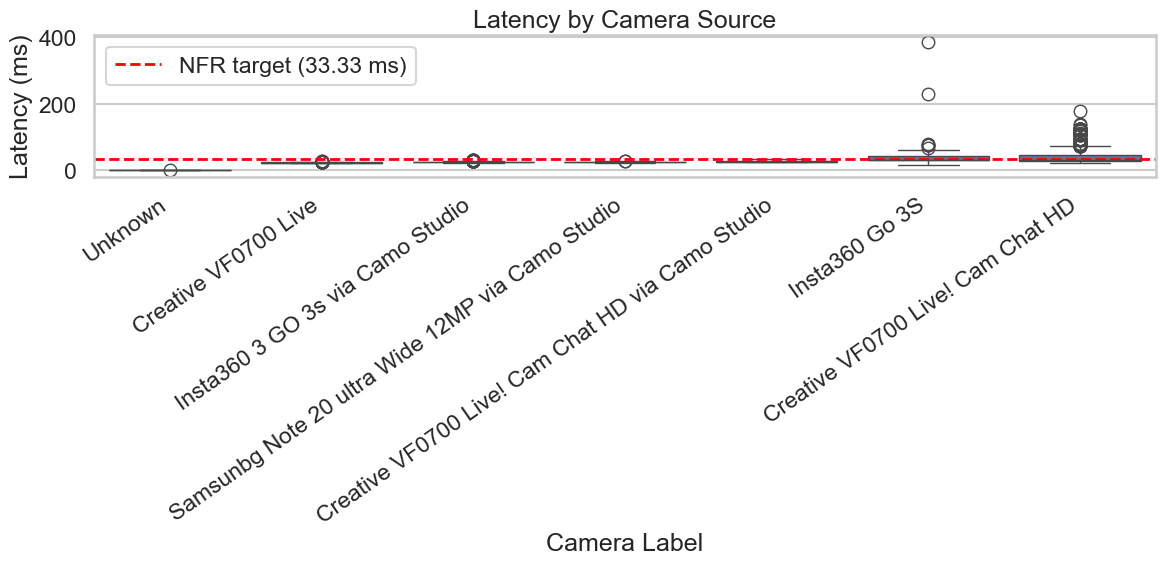

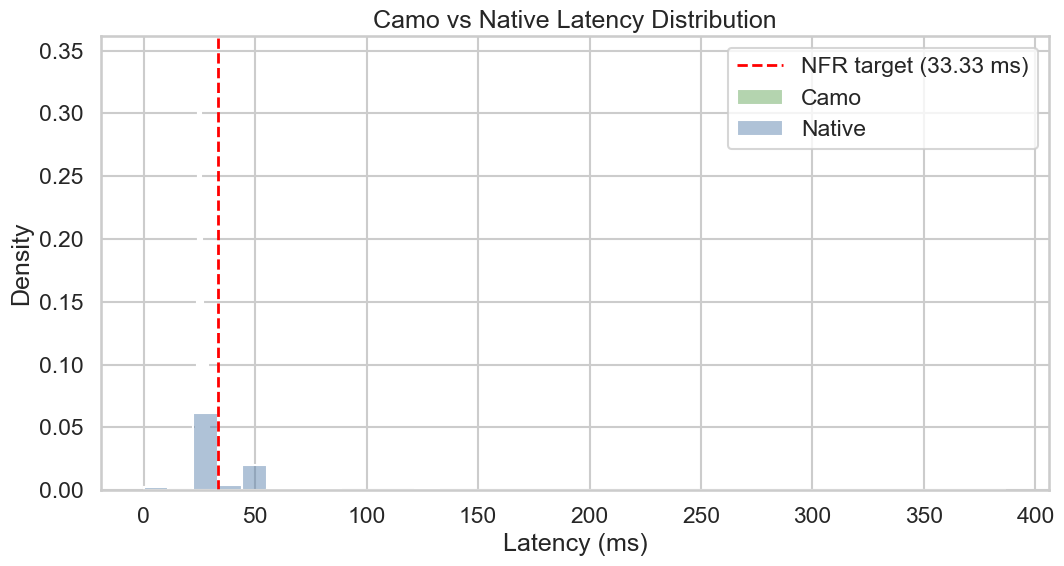

In [6]:
# Figure 4.1: Histogram + box plot with NFR line
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
sns.histplot(df['latency_ms'], bins=40, kde=True, ax=axes[0], color='#4E79A7')
axes[0].axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
axes[0].set_title('Latency Distribution')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(y=df['latency_ms'], ax=axes[1], color='#A0CBE8')
axes[1].axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Latency Box Plot')
axes[1].set_ylabel('Latency (ms)')

fig.tight_layout()
fig.savefig('fig_4_1_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.2: Box plot per camera with Camo vs Native colors
cam_order = table_4_2.sort_values('median')['camera_label'].tolist()
cam_source = df[['camera_label', 'source_type']].drop_duplicates().set_index('camera_label')['source_type'].to_dict()
palette_map = {cam: ('#59A14F' if cam_source.get(cam) == 'Camo' else '#4E79A7') for cam in cam_order}

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, palette=palette_map)
plt.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency by Camera Source')
plt.xlabel('Camera Label')
plt.ylabel('Latency (ms)')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_2_latency_by_camera.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.3: Overlaid histograms for Camo vs Native
plt.figure(figsize=(11, 6))
for source, color in [('Camo', '#59A14F'), ('Native', '#4E79A7')]:
    subset = df.loc[df['source_type'] == source, 'latency_ms']
    if not subset.empty:
        sns.histplot(subset, bins=35, stat='density', alpha=0.45, label=source, color=color)

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Camo vs Native Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_3_camo_vs_native.png', dpi=150, bbox_inches='tight')
plt.show()

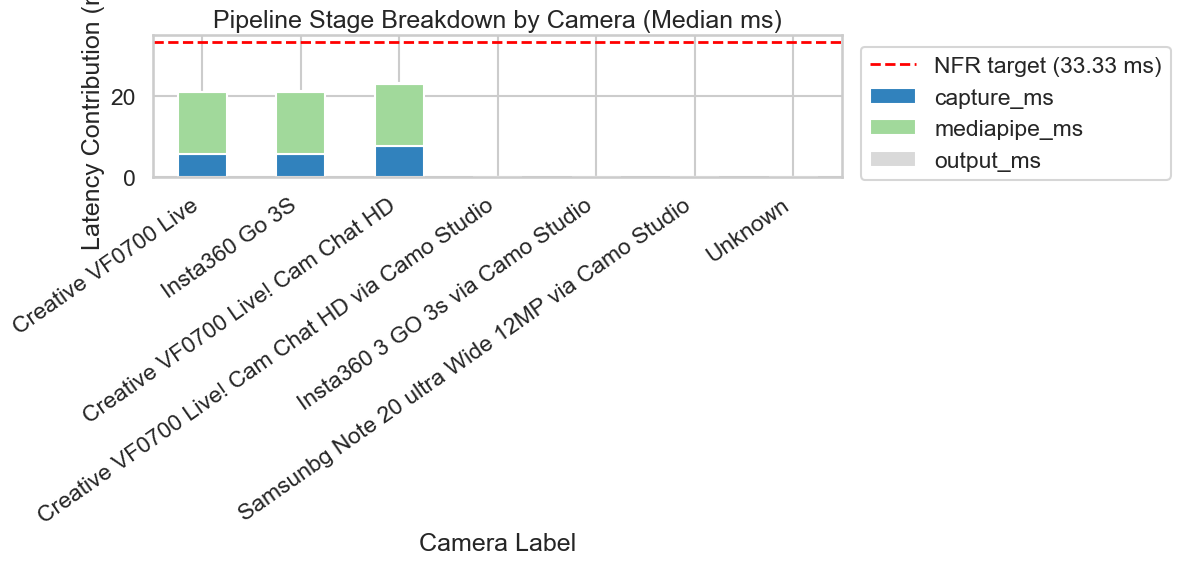

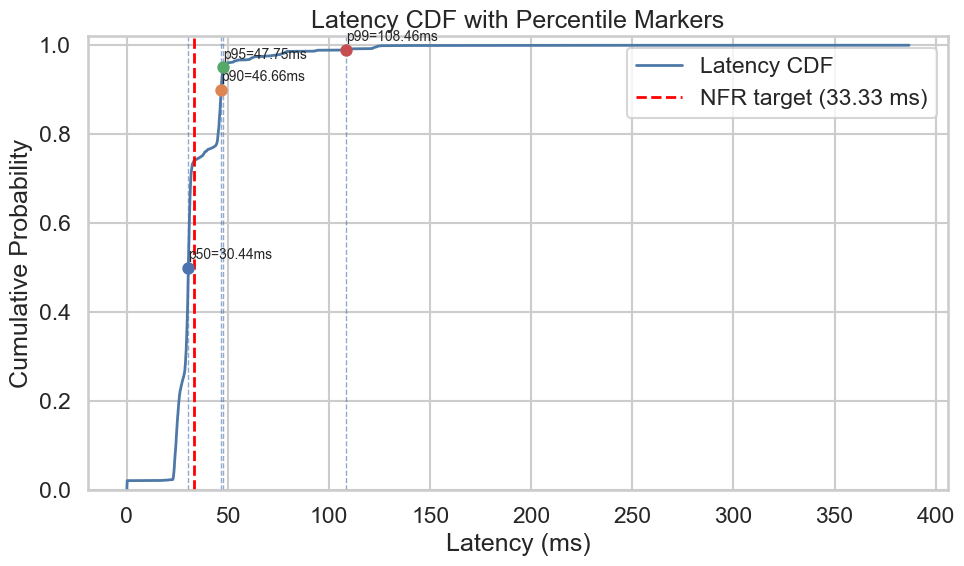

In [7]:
# Figure 4.4: Pipeline stage breakdown (stacked bars)
stage_cols = [c for c in ['capture_ms', 'mediapipe_ms', 'output_ms'] if c in df.columns]
if len(stage_cols) >= 1:
    stage_df = df.groupby('camera_label', dropna=False)[stage_cols].median().sort_values(by=stage_cols[0])
    ax = stage_df.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(12, 6))
    ax.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
    ax.set_title('Pipeline Stage Breakdown by Camera (Median ms)')
    ax.set_xlabel('Camera Label')
    ax.set_ylabel('Latency Contribution (ms)')
    plt.xticks(rotation=35, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.savefig('fig_4_4_pipeline_stages.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped Figure 4.4: no stage columns found.')

# Figure 4.5: Latency CDF with percentile markers
sorted_lat = np.sort(df['latency_ms'].to_numpy())
cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)

plt.figure(figsize=(10, 6))
plt.plot(sorted_lat, cdf, color='#4E79A7', linewidth=2, label='Latency CDF')

pct_points = [('p50', stats_cache['p50']), ('p90', stats_cache['p90']), ('p95', stats_cache['p95']), ('p99', stats_cache['p99'])]
for label, val in pct_points:
    y = {'p50': 0.50, 'p90': 0.90, 'p95': 0.95, 'p99': 0.99}[label]
    plt.scatter([val], [y], s=55, zorder=5)
    plt.axvline(val, linestyle='--', linewidth=1, alpha=0.6)
    plt.text(val, y + 0.02, f'{label}={val:.2f}ms', fontsize=10, ha='left')

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency CDF with Percentile Markers')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_5_latency_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
overall_median = stats_cache['median']
verdict = stats_cache['verdict']

camo_row = table_4_3.loc[table_4_3['source_type'] == 'Camo']
native_row = table_4_3.loc[table_4_3['source_type'] == 'Native']

if not camo_row.empty and not native_row.empty:
    camo_median = float(camo_row['median_ms'].iloc[0])
    native_median = float(native_row['median_ms'].iloc[0])
    camo_comp = float(camo_row['compliance_pct'].iloc[0])
    native_comp = float(native_row['compliance_pct'].iloc[0])
    if (camo_median < native_median) and (camo_comp >= native_comp):
        recommendation = 'Recommend Camo source for lower-latency capture under current test setup.'
    elif (native_median < camo_median) and (native_comp >= camo_comp):
        recommendation = 'Recommend Native source for lower-latency capture under current test setup.'
    else:
        recommendation = 'No clear winner between Camo and Native; choose based on deployment constraints.'
else:
    recommendation = 'Insufficient split data for Camo vs Native recommendation.'

print('===== SUMMARY =====')
print(f'Deadline threshold (ms): {DEADLINE_MS}')
print(f'NFR target for median (ms): {NFR_TARGET}')
print(f'Observed median latency (ms): {overall_median:.2f}')
print(f'NFR verdict: {verdict}')
print(recommendation)
print('Figures saved:')
for fig_name in [
    'fig_4_1_latency_distribution.png',
    'fig_4_2_latency_by_camera.png',
    'fig_4_3_camo_vs_native.png',
    'fig_4_4_pipeline_stages.png',
    'fig_4_5_latency_cdf.png'
]:
    print(f' - {Path(fig_name).resolve()}')

===== SUMMARY =====
Deadline threshold (ms): 33.33
NFR target for median (ms): 33.0
Observed median latency (ms): 30.44
NFR verdict: PASS
Recommend Camo source for lower-latency capture under current test setup.
Figures saved:
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\fig_4_1_latency_distribution.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\fig_4_2_latency_by_camera.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\fig_4_3_camo_vs_native.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\fig_4_4_pipeline_stages.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\fig_4_5_latency_cdf.png
